In [1]:
import os
import random
import xml.etree.ElementTree as ET
import json
from datetime import datetime

# 1. 读取标题
with open('books.txt', 'r', encoding='utf-8') as f:
    titles = [line.strip() for line in f if line.strip()]

# 2. 随机划分
random.seed(42)
random.shuffle(titles)
train_titles = titles[:84]
val_titles = titles[84:89]
test_titles = titles[89:]

# 3. 解析XML并生成COCO格式（只提取text框）
def parse_xml_text(xml_path, categories, image_id_start=0, annotation_id_start=0):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    images = []
    annotations = []
    image_id = image_id_start
    annotation_id = annotation_id_start
    category_map = {cat['name']: cat['id'] for cat in categories}
    book_title = root.attrib['title']
    for page in root.find('pages').iter('page'):
        page_index = int(page.attrib['index'])
        width = int(page.attrib.get('width', 0))
        height = int(page.attrib.get('height', 0))
        file_name = os.path.join(book_title, f"{page_index:03d}.jpg").replace("\\", "/")
        images.append({
            "id": image_id,
            "file_name": file_name,
            "width": width,
            "height": height
        })
        for obj in page.iter('text'):
            xmin = float(obj.attrib['xmin'])
            ymin = float(obj.attrib['ymin'])
            xmax = float(obj.attrib['xmax'])
            ymax = float(obj.attrib['ymax'])
            w = xmax - xmin
            h = ymax - ymin
            bbox = [xmin, ymin, w, h]
            area = w * h
            annotations.append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": category_map['text'],
                "bbox": bbox,
                "area": area,
                "iscrowd": 0
            })
            annotation_id += 1
        image_id += 1
    return images, annotations, image_id, annotation_id

def build_coco_text(titles, xml_dir, categories, info):
    images, annotations = [], []
    image_id = 0
    annotation_id = 0
    for title in titles:
        xml_path = os.path.join(xml_dir, f"{title}.xml")
        img, ann, image_id, annotation_id = parse_xml_text(xml_path, categories, image_id, annotation_id)
        images.extend(img)
        annotations.extend(ann)
    return {
        "info": info,
        "images": images,
        "annotations": annotations,
        "categories": categories
    }

categories = [
    {"id": 1, "name": "text"}
]

info = {
    "description": "Manga109 text detection dataset in COCO format",
    "version": "1.0",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "contributor": "YourName",
    "url": "https://manga109.org/",
    "year": datetime.now().year
}

train_coco = build_coco_text(train_titles, "annotations", categories, info)
val_coco = build_coco_text(val_titles, "annotations", categories, info)
test_coco = build_coco_text(test_titles, "annotations", categories, info)

# 4. 保存到 test 文件夹
os.makedirs('text', exist_ok=True)
with open('text/train_text.json', 'w', encoding='utf-8') as f:
    json.dump(train_coco, f, ensure_ascii=False, indent=2)
with open('text/val_text.json', 'w', encoding='utf-8') as f:
    json.dump(val_coco, f, ensure_ascii=False, indent=2)
with open('text/test_text.json', 'w', encoding='utf-8') as f:
    json.dump(test_coco, f, ensure_ascii=False, indent=2)


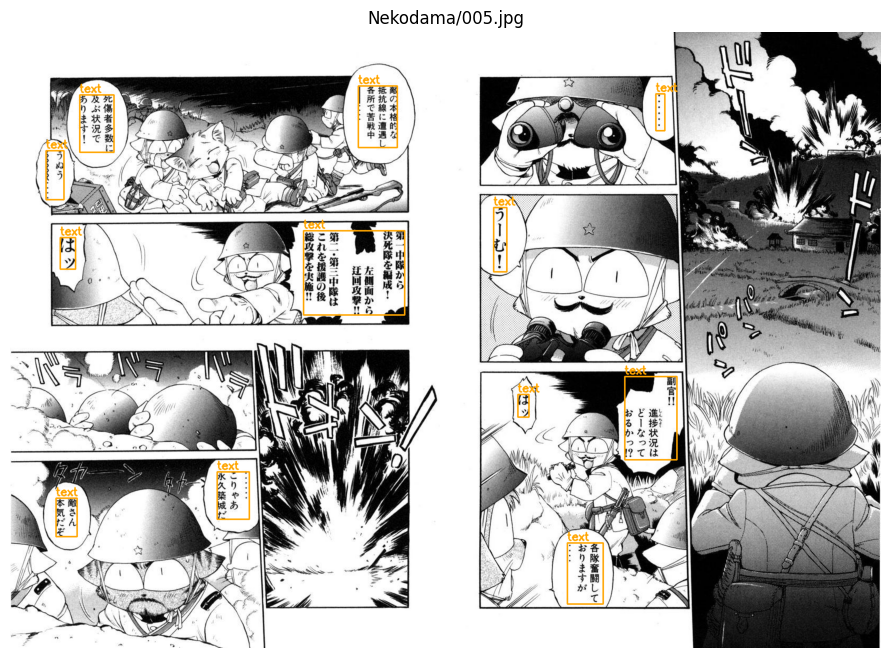

In [2]:
import json
import cv2
import matplotlib.pyplot as plt
import os

# ====== 直接在这里设置参数 ======
coco_json_path = 'text/train_text.json'  # text类COCO格式标注文件
img_root = 'images'                      # 图片根目录
img_file_name = 'Nekodama/005.jpg'       # 你要验证的图片路径（COCO里的file_name字段）
# =================================

# 1. 读取COCO标注
with open(coco_json_path, 'r', encoding='utf-8') as f:
    coco = json.load(f)

# 2. 找到图片信息
img_info = None
for img in coco['images']:
    if img['file_name'] == img_file_name:
        img_info = img
        break

if img_info is None:
    raise ValueError(f"未找到图片 {img_file_name} 的标注信息")

# 3. 找到该图片的所有标注
anns = [ann for ann in coco['annotations'] if ann['image_id'] == img_info['id']]
cat_map = {cat['id']: cat['name'] for cat in coco['categories']}

# 4. 读取图片
img_path = os.path.join(img_root, img_file_name)
if not os.path.exists(img_path):
    raise FileNotFoundError(f"图片未找到: {img_path}")
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"图片无法读取: {img_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 5. 画框
for ann in anns:
    x, y, w, h = map(int, ann['bbox'])
    cat_name = cat_map[ann['category_id']]
    color = (255, 165, 0)  # 橙色用于text
    cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
    cv2.putText(image, cat_name, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

# 6. 显示图片
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')
plt.title(img_file_name)
plt.show()


In [3]:
import json
import os

# 修改为你的 COCO 标注文件路径
coco_jsons = {
    "train": "./text/train_text.json",
    "val": "./text/val_text.json",
    "test": "./text/test_text.json"
}

for split, json_file in coco_jsons.items():
    if not os.path.exists(json_file):
        print(f"{split} 标注文件 {json_file} 不存在！")
        continue
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        num_images = len(data.get("images", []))
        print(f"{split} 集合有 {num_images} 张图片")

train 集合有 8145 张图片
val 集合有 410 张图片
test 集合有 2047 张图片
